Dataset Loaded Successfully
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

After Encoding:
   Year  Selling_Price  Present_Price  Kms_Driven  Owner  Fuel_Type_Diesel  \
0  2014           3.35           5.59       27000      0             False   
1  2013           4.75           9.54       43000      0              True   
2  2017           7.25           9.85        6900      0             Fal

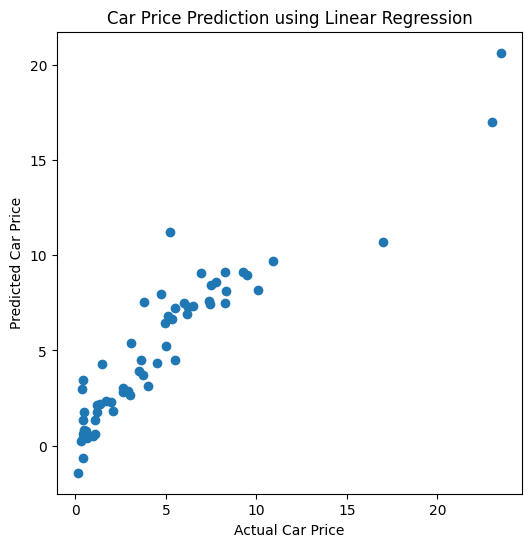

In [ ]:
# Car Price Prediction System
# Using Linear Regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 2. Load Dataset
url = "https://raw.githubusercontent.com/krishnaik06/Car-Price-Prediction/master/car%20data.csv"
df = pd.read_csv(url)

print("Dataset Loaded Successfully")
print(df.head())


# 3. Drop Car_Name (string column)
df.drop("Car_Name", axis=1, inplace=True)


# 4. Convert Categorical Columns to Numeric
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Seller_Type", "Transmission"],
    drop_first=True
)

print("\nAfter Encoding:")
print(df.head())


# 5. Split Features and Target
X = df.drop("Selling_Price", axis=1)   # 2D DataFrame
y = df["Selling_Price"]                # 1D Series


# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# 7. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Trained Successfully")


# 8. Make Predictions
y_pred = model.predict(X_test)


# 9. Evaluate Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


# 10. Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Car Price")
plt.ylabel("Predicted Car Price")
plt.title("Car Price Prediction using Linear Regression")
plt.show()
